# Aufgabe 4

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

In [24]:
mandrill_hbars_orig = imread("mandrill_hBars.png")
mandrill_rings_orig = imread("mandrill_rings.png")

## 4.1

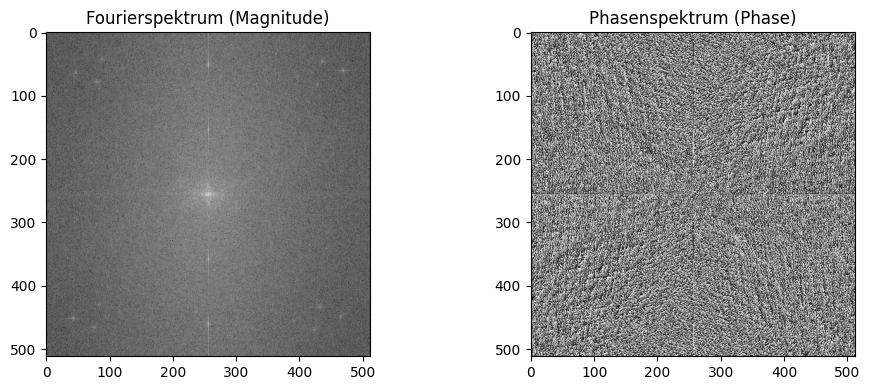

In [25]:
F = np.fft.fft2(mandrill_hbars_orig)    # Fouriertransformation
F = np.fft.fftshift(F)                  # Zentrierung

magnitude_hbars = np.log(np.abs(F))
phase_hbars = np.angle(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(magnitude_hbars, cmap='gray'); axes[0].set_title('Fourierspektrum (Magnitude)')
axes[1].imshow(phase_hbars, cmap='gray');     axes[1].set_title('Phasenspektrum (Phase)')
plt.tight_layout()
plt.show()

Die Störpunkte im Fourierspektrum, die auf die periodische Störung hinweisen, sind die Punkte bei etwa (50, 250), (150, 250), (350, 250), (450, 250)

## 4.2

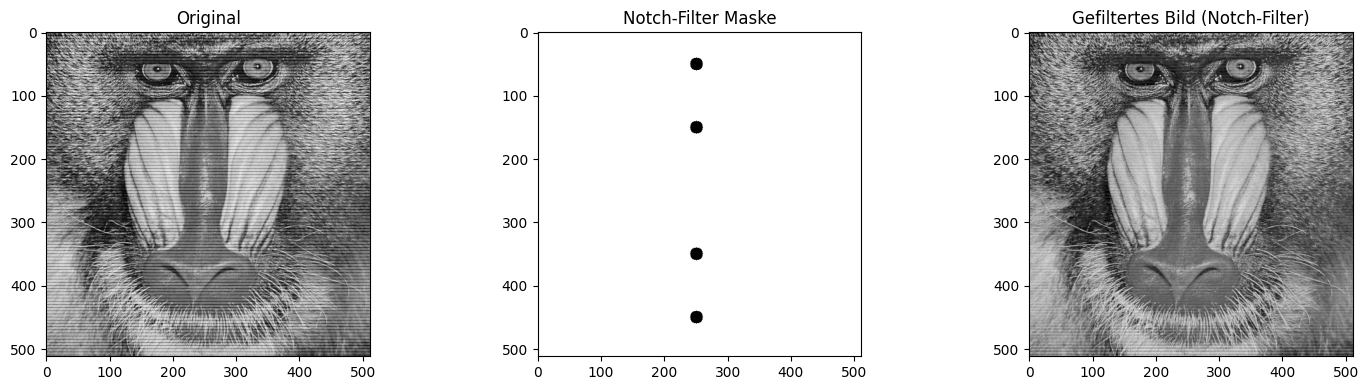

In [26]:

F = np.fft.fft2(mandrill_hbars_orig)
F_shifted = np.fft.fftshift(F)

# Notch-Filter Maske erstellen
rows, cols = mandrill_hbars_orig.shape[:2]
mask = np.ones((rows, cols), dtype=float)

# Störpunkte aus Aufgabe 4.1 (Zeile, Spalte) mit Radius ausblenden
notch_points = [(50, 250), (150, 250), (350, 250), (450, 250)]
radius = 10

Y, X = np.ogrid[:rows, :cols]
for (r, c) in notch_points:
    dist = np.sqrt((X - c)**2 + (Y - r)**2)
    mask[dist <= radius] = 0

# Notch-Filter anwenden
F_filtered = F_shifted * mask

# Rücktransformation
F_back = np.fft.ifftshift(F_filtered)
filtered_image = np.real(np.fft.ifft2(F_back))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(mandrill_hbars_orig, cmap='gray'), axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray'), axes[1].set_title('Notch-Filter Maske')
axes[2].imshow(np.clip(filtered_image, 0, 255).astype(np.uint8), cmap='gray')
axes[2].set_title('Gefiltertes Bild (Notch-Filter)')
plt.tight_layout()
plt.show()


## 4.3

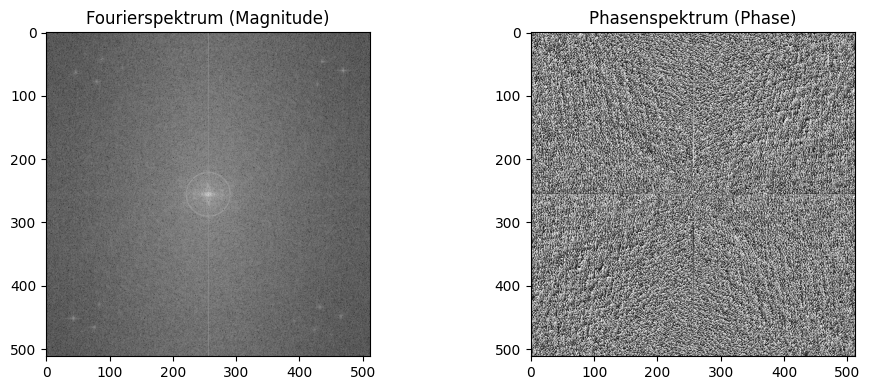

In [27]:
F = np.fft.fft2(mandrill_rings_orig)    # Fouriertransformation
F = np.fft.fftshift(F)                  # Zentrierung

magnitude_rings = np.log(np.abs(F))
phase_rings = np.angle(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(magnitude_rings, cmap='gray'); axes[0].set_title('Fourierspektrum (Magnitude)')
axes[1].imshow(phase_rings, cmap='gray');     axes[1].set_title('Phasenspektrum (Phase)')
plt.tight_layout()
plt.show()

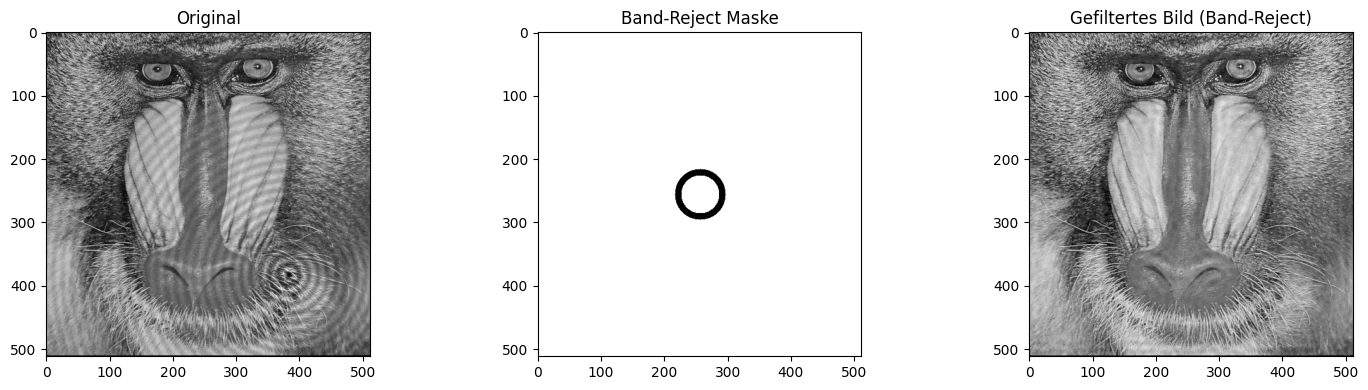

In [29]:

F = np.fft.fft2(mandrill_rings_orig)
F_shifted = np.fft.fftshift(F)

# Band-Reject (ringförmiger Notch) Filter
rows, cols = mandrill_rings_orig.shape[:2]
cy, cx = rows // 2, cols // 2  # Spektrum-Mittelpunkt

Y, X = np.ogrid[:rows, :cols]
dist_center = np.sqrt((X - cx)**2 + (Y - cy)**2)

# Frequenzring aus dem Spektrum ausblenden (Radius aus Aufgabe 4.3)
r_inner = 30
r_outer = 40

mask = np.ones((rows, cols), dtype=float)
mask[(dist_center >= r_inner) & (dist_center <= r_outer)] = 0

# Filter anwenden und rücktransformieren
F_filtered = F_shifted * mask
F_back = np.fft.ifftshift(F_filtered)
filtered_image = np.real(np.fft.ifft2(F_back))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(mandrill_rings_orig, cmap='gray'), axes[0].set_title('Original')
axes[1].imshow(mask, cmap='gray'), axes[1].set_title('Band-Reject Maske')
axes[2].imshow(np.clip(filtered_image, 0, 255).astype(np.uint8), cmap='gray')
axes[2].set_title('Gefiltertes Bild (Band-Reject)')
plt.tight_layout()
plt.show()


Bandpass filter, der den kreis rausfiltert